# Avaliação do Modelo — LightGBM

Análise de performance e interpretabilidade do modelo treinado em `train.py`.

Artifatos esperados na mesma pasta:
- `feature_importance.csv` — gerado pelo `train.py`
- `submission.csv` — predições do conjunto de teste

In [1]:
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
import sys, os

# Sobe um nível: de Analysis/ para a raiz do projeto (CreditRisk/)
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import ABT_DATA_PATH, TARGET_COLUMN

sns.set_theme(style='whitegrid')

# Carrega importância de features
feat_imp = pd.read_csv(os.path.join(PROJECT_ROOT, 'feature_importance.csv'))
print(f'Folds registrados: {feat_imp["fold"].nunique()}')
feat_imp.head()

Folds registrados: 5


,feature,importance,fold
0,NAME_CONTRACT_TYPE,0,1
1,CODE_GENDER,148,1
2,FLAG_OWN_CAR,15,1
3,FLAG_OWN_REALTY,13,1
4,CNT_CHILDREN,20,1


## 1. Top 40 Features — Importância Média entre Folds

A média é mais estável do que a importância de um único fold, especialmente
para features correlacionadas que podem ter importância 'diluída' entre si.

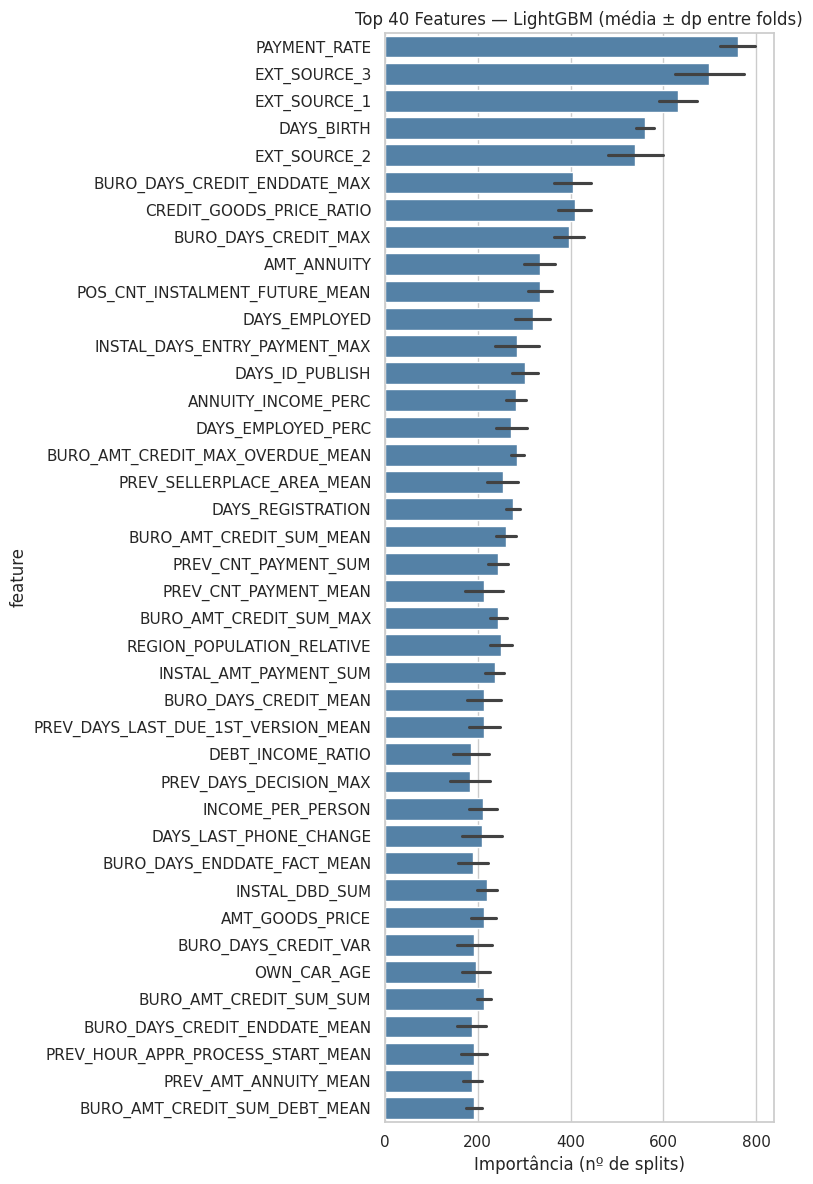

In [2]:
top_features = (
    feat_imp.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .head(40)
)

best = feat_imp[feat_imp['feature'].isin(top_features.index)]

fig, ax = plt.subplots(figsize=(8, 12))
sns.barplot(
    data=best.sort_values('importance', ascending=False),
    x='importance', y='feature', ax=ax,
    color='steelblue', errorbar='sd',   # barra de erro = desvio padrão entre folds
)
ax.set_title('Top 40 Features — LightGBM (média ± dp entre folds)')
ax.set_xlabel('Importância (nº de splits)')
plt.tight_layout()
plt.savefig('lgbm_importances.png', dpi=150)
plt.show()

## 2. Variabilidade da Importância entre Folds

Features com alto desvio padrão entre folds podem indicar instabilidade
ou correlação com outras features. Atenção especial para features no topo
mas com desvio alto.

In [3]:
stability = (
    feat_imp.groupby('feature')['importance']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=False)
    .head(20)
)
stability['cv'] = stability['std'] / stability['mean'].replace(0, np.nan)  # coeficiente de variação
stability.style.background_gradient(cmap='RdYlGn_r', subset=['cv'])

,mean,std,cv
feature,,,
PAYMENT_RATE,760.200000,37.771683,0.049687
EXT_SOURCE_3,698.600000,73.839691,0.105697
EXT_SOURCE_1,631.600000,41.434285,0.065602
DAYS_BIRTH,560.200000,18.376616,0.032804
EXT_SOURCE_2,539.600000,59.112604,0.109549
CREDIT_GOODS_PRICE_RATIO,409.400000,35.704341,0.087211
BURO_DAYS_CREDIT_ENDDATE_MAX,404.800000,40.357155,0.099697
BURO_DAYS_CREDIT_MAX,396.600000,32.168307,0.081110
POS_CNT_INSTALMENT_FUTURE_MEAN,334.400000,26.311594,0.078683


## 3. Distribuição das Predições

A distribuição das probabilidades preditas indica se o modelo está bem calibrado:
- Concentração perto de 0.5 pode indicar modelo sem confiança
- Boa separação entre as distribuições de TARGET=0 e TARGET=1 é o desejado

Predições — min: 0.0012 | max: 0.7560 | média: 0.0747


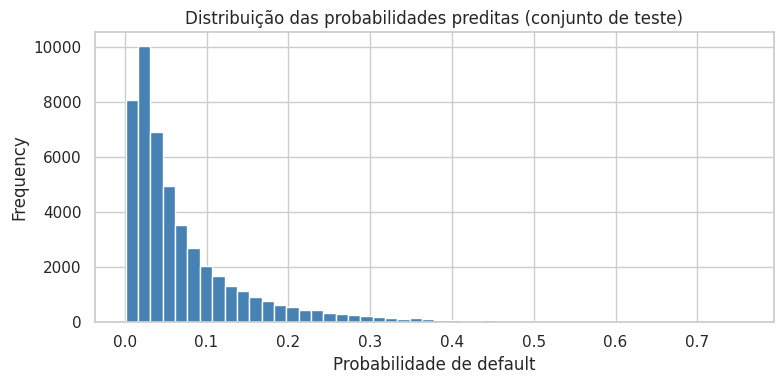

In [4]:
sub = pd.read_csv(os.path.join(PROJECT_ROOT, 'submission.csv'))

print(f'Predições — min: {sub[TARGET_COLUMN].min():.4f} | max: {sub[TARGET_COLUMN].max():.4f} | média: {sub[TARGET_COLUMN].mean():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
sub[TARGET_COLUMN].plot.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribuição das probabilidades preditas (conjunto de teste)')
ax.set_xlabel('Probabilidade de default')
plt.tight_layout()
plt.show()

## 4. Análise de Features por Grupo

Agrupa features pelo prefixo (BURO_, PREV_, POS_, INSTAL_, CC_) para entender
qual fonte de dados contribui mais para o modelo.

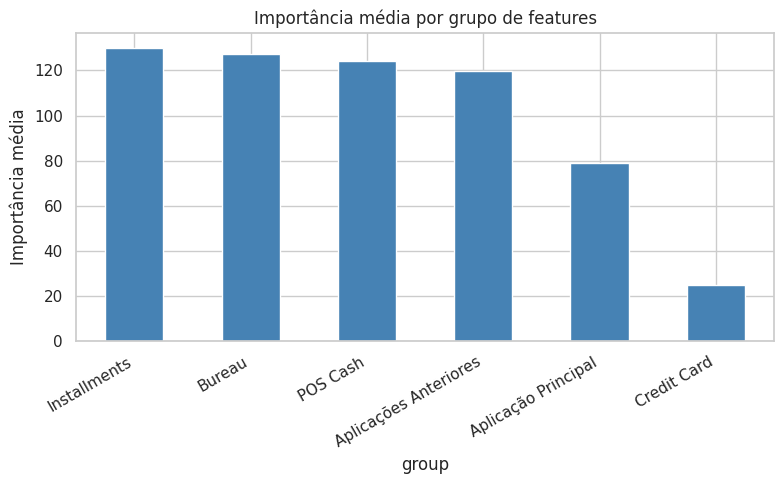

In [5]:
prefix_map = {
    'BURO_':    'Bureau',
    'ACTIVE_':  'Bureau Ativo',
    'CLOSED_':  'Bureau Encerrado',
    'PREV_':    'Aplicações Anteriores',
    'APPROVED_':'Aprovadas',
    'REFUSED_': 'Recusadas',
    'POS_':     'POS Cash',
    'INSTAL_':  'Installments',
    'CC_':      'Credit Card',
}

def get_group(feature):
    for prefix, group in prefix_map.items():
        if feature.startswith(prefix):
            return group
    return 'Aplicação Principal'

feat_imp['group'] = feat_imp['feature'].apply(get_group)
group_imp = feat_imp.groupby('group')['importance'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
group_imp.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importância média por grupo de features')
ax.set_ylabel('Importância média')
ax.set_xticklabels(group_imp.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()